# Prédiction de matchs de football — architecture hybride (projet académique)

**Question** : quelle architecture, sans les cotes en entrée, produit les probabilités 1X2 les mieux calibrées, et à quelle distance est-elle des cotes des bookmakers ?

**Architecture** (cf. document « État de l'art et architecture ») :
1. Données : 38 championnats, 2000 → 2026 (football-data.co.uk + ClubElo, via le dataset Club-Football-Match-Data).
2. États d'équipe calculés **avant** chaque match : forme (moyennes mobiles), Elo, pi-ratings (Constantinou & Fenton 2013), GAP ratings (Wheatcroft 2021), Dixon-Coles réestimé chaque mois (penaltyblog).
3. Modèles de base calibrés sur la saison précédente : XGBoost, LightGBM, CatBoost, régression logistique.
4. Ensemble : moyenne des probabilités.
5. Évaluation **walk-forward** saison par saison, log loss / RPS / Brier / ECE, tests appariés, cotes (méthode de Shin) comme référence externe.

Durée : ~10–15 min sur un runtime CPU Colab gratuit (réduire `TEST_SEASONS` pour aller plus vite). Aucun pari : les cotes ne servent qu'à la comparaison.

In [1]:
# penaltyblog : on installe sans la dépendance « socks » qui échoue parfois à la compilation
!pip -q install catboost
!pip -q install --no-deps penaltyblog
!pip -q install beautifulsoup4 cssselect cython fsspec html5lib lxml networkx orjson plotly pulp scipy tabulate tqdm

In [2]:
import time, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.optimize import brentq
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from penaltyblog.models import DixonColesGoalModel, dixon_coles_weights
warnings.filterwarnings("ignore"); pd.set_option("display.width", 200)

DATA_URL = "https://raw.githubusercontent.com/xgabora/Club-Football-Match-Data-2000-2025/main/data/Matches.csv"
BIG = ["E0", "SP1", "I1", "D1", "F1"]        # ligues évaluées
FIRST_SEASON, ROLL = 2006, 5
TEST_SEASONS = list(range(2018, 2026))       # 2018/19 → 2025/26 ; la 1re sert à amorcer le stacking

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Données (toutes les ligues, pour les ratings et le transfert)

In [3]:
raw = pd.read_csv(DATA_URL, parse_dates=["MatchDate"], low_memory=False)
df = raw.copy()
df["Season"] = np.where(df.MatchDate.dt.month >= 7, df.MatchDate.dt.year, df.MatchDate.dt.year - 1)
df = df[df.Season >= FIRST_SEASON - 1].dropna(subset=["FTResult", "FTHome", "FTAway"])
df = df.drop(columns=[c for c in df.columns if c.startswith("C_")])   # calculées pendant le match → fuite
df = df.sort_values(["MatchDate", "Division", "HomeTeam"]).reset_index(drop=True)
df["match_id"] = np.arange(len(df))
df["y"] = df.FTResult.map({"H": 0, "D": 1, "A": 2})
df["goals"] = df.FTHome + df.FTAway; df["over25"] = (df.goals > 2.5).astype(int)
print(raw.shape, "→", len(df), "matchs de", df.Division.nunique(), "ligues, jusqu'au", df.MatchDate.max().date())

(238858, 48) → 211404 matchs de 38 ligues, jusqu'au 2026-09-03


## 2. États d'équipe (sans fuite de données)
### 2.1 Forme : moyennes mobiles décalées (`shift(1)`)

In [4]:
def implied(odds_h, odds_d, odds_a):
    inv = np.c_[1 / odds_h, 1 / odds_d, 1 / odds_a]
    over = inv.sum(1, keepdims=True)
    return inv / over, over.ravel() - 1

def to_long(d):
    base = ["match_id", "MatchDate", "Season", "Division"]
    h = d[base].copy(); a = d[base].copy()
    h["team"], h["opp"], h["is_home"] = d.HomeTeam, d.AwayTeam, 1
    a["team"], a["opp"], a["is_home"] = d.AwayTeam, d.HomeTeam, 0
    pairs = {"gf": ("FTHome", "FTAway"), "ga": ("FTAway", "FTHome"), "sh_f": ("HomeShots", "AwayShots"),
             "sh_a": ("AwayShots", "HomeShots"), "sot_f": ("HomeTarget", "AwayTarget"),
             "sot_a": ("AwayTarget", "HomeTarget"), "cor_f": ("HomeCorners", "AwayCorners"),
             "cor_a": ("AwayCorners", "HomeCorners")}
    for k, (hc, ac) in pairs.items():
        h[k], a[k] = d[hc].values, d[ac].values
    L = pd.concat([h, a], ignore_index=True)
    L["pts"] = np.select([L.gf > L.ga, L.gf == L.ga], [3, 1], 0).astype(float)
    L.loc[L.gf.isna(), "pts"] = np.nan                     # matchs futurs
    return L.sort_values(["team", "MatchDate", "match_id"]).reset_index(drop=True)

def team_features(L, n=ROLL):
    g = L.groupby("team", sort=False)
    stats = ["gf", "ga", "sh_f", "sh_a", "sot_f", "sot_a", "cor_f", "cor_a", "pts"]
    past = g[stats].shift(1)                               # ← la ligne du match lui-même est exclue
    F = pd.DataFrame(index=L.index)
    for s in stats:
        F[f"{s}_r{n}"] = past[s].groupby(L.team).transform(lambda x: x.rolling(n, min_periods=3).mean())
        F[f"{s}_ewm"] = past[s].groupby(L.team).transform(lambda x: x.ewm(span=10, min_periods=3).mean())
    F["pts_r10"] = past["pts"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).mean())
    # conversion : buts / tirs cadrés, sur 10 matchs
    gf10 = past["gf"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).sum())
    sot10 = past["sot_f"].groupby(L.team).transform(lambda x: x.rolling(10, min_periods=5).sum())
    F["conv_r10"] = gf10 / sot10.replace(0, np.nan)
    # forme spécifique domicile / extérieur
    gv = L.groupby(["team", "is_home"], sort=False)
    pv = gv[["pts", "gf", "ga"]].shift(1)
    for s in ["pts", "gf", "ga"]:
        F[f"{s}_venue_r{n}"] = pv[s].groupby([L.team, L.is_home]).transform(lambda x: x.rolling(n, min_periods=2).mean())
    # points par match depuis le début de saison
    ps = L.groupby(["team", "Season"], sort=False)["pts"].shift(1)
    F["ppg_season"] = ps.groupby([L.team, L.Season]).transform(lambda x: x.expanding().mean())
    F["n_played_season"] = ps.groupby([L.team, L.Season]).transform(lambda x: x.notna().cumsum())
    # repos (jours depuis le dernier match de championnat)
    F["rest_days"] = g.MatchDate.diff().dt.days.clip(upper=21)
    return pd.concat([L[["match_id", "team", "is_home"]], F], axis=1)

def h2h_feature(d, n=5):
    """Différence de buts moyenne des n dernières confrontations, du point de vue de l'équipe à domicile."""
    first = np.where(d.HomeTeam < d.AwayTeam, d.HomeTeam, d.AwayTeam)
    key = first + "|" + np.where(d.HomeTeam < d.AwayTeam, d.AwayTeam, d.HomeTeam)
    gd_first = np.where(d.HomeTeam == first, d.FTHome - d.FTAway, d.FTAway - d.FTHome)
    t = pd.DataFrame({"key": key, "gd": gd_first, "date": d.MatchDate}).sort_values("date", kind="stable")
    t["h2h"] = t.groupby("key").gd.transform(lambda x: x.shift(1).rolling(n, min_periods=1).mean())
    t = t.reindex(d.index)
    return np.where(d.HomeTeam == first, t.h2h, -t.h2h)

def build_features(d):
    L = to_long(d)
    TF = team_features(L)
    H = TF[TF.is_home == 1].drop(columns=["team", "is_home"]).add_prefix("h_").rename(columns={"h_match_id": "match_id"})
    A = TF[TF.is_home == 0].drop(columns=["team", "is_home"]).add_prefix("a_").rename(columns={"a_match_id": "match_id"})
    X = d.merge(H, on="match_id").merge(A, on="match_id")
    # différences domicile − extérieur
    for c in [c[2:] for c in H.columns if c.startswith("h_")]:
        X[f"d_{c}"] = X[f"h_{c}"] - X[f"a_{c}"]
    X["elo_diff"] = X.HomeElo - X.AwayElo
    X["h2h_gd"] = h2h_feature(X)
    # marché (cotes d'avant-match)
    P, m = implied(X.OddHome.values, X.OddDraw.values, X.OddAway.values)
    X["mkt_pH"], X["mkt_pD"], X["mkt_pA"], X["mkt_margin"] = P[:, 0], P[:, 1], P[:, 2], m
    X["mkt_disp_H"] = X.MaxHome / X.OddHome - 1            # dispersion des cotes entre bookmakers
    X["mkt_disp_A"] = X.MaxAway / X.OddAway - 1
    ou = np.c_[1 / X.Over25, 1 / X.Under25]
    X["mkt_pOver"] = ou[:, 0] / ou.sum(1)
    return X

t0 = time.time()
X = build_features(df)
X = X[X.Season >= FIRST_SEASON].reset_index(drop=True)
print(X.shape, f"{time.time()-t0:.0f}s")

(204080, 134) 28s


### 2.2 Pi-ratings (Constantinou & Fenton, 2013) et GAP ratings (Wheatcroft, 2021)
Valeurs enregistrées **avant** la mise à jour de chaque match, sur toutes les ligues.

In [5]:
def pi_ratings(d, lr=0.035, gamma=0.7, b=10, c=3):
    R, out = {}, np.zeros((len(d), 4))
    for i, (h, a, gh, ga) in enumerate(zip(d.HomeTeam.values, d.AwayTeam.values, d.FTHome.values, d.FTAway.values)):
        rh = R.setdefault(h, [0.0, 0.0]); ra = R.setdefault(a, [0.0, 0.0])      # [domicile, extérieur]
        out[i] = rh[0], rh[1], ra[0], ra[1]
        if np.isnan(gh): continue
        eh = np.sign(rh[0]) * (b ** (abs(rh[0]) / c) - 1); ea = np.sign(ra[1]) * (b ** (abs(ra[1]) / c) - 1)
        e = (gh - ga) - (eh - ea); psi = c * np.log10(1 + abs(e)); s = psi if e > 0 else -psi
        o0, o1 = rh[0], ra[1]
        rh[0] += s * lr; rh[1] += (rh[0] - o0) * gamma
        ra[1] -= s * lr; ra[0] += (ra[1] - o1) * gamma
    return out

def gap(d, hs, as_, lam=0.1, p1=0.5, p2=0.5):
    R = {}; out = np.full((len(d), 2), np.nan)
    for i, (h, a, sh, sa) in enumerate(zip(d.HomeTeam.values, d.AwayTeam.values, d[hs].values, d[as_].values)):
        rh = R.get(h); ra = R.get(a)
        if rh is not None and ra is not None:
            out[i] = (rh[0] + ra[3]) / 2, (ra[1] + rh[2]) / 2
        if np.isnan(sh) or np.isnan(sa): continue
        if rh is None: rh = R.setdefault(h, [sh, sa, sa, sh])       # [att_dom, att_ext, def_dom, def_ext]
        if ra is None: ra = R.setdefault(a, [sh, sa, sa, sh])
        eh = (rh[0] + ra[3]) / 2; ea = (ra[1] + rh[2]) / 2
        rh[0] = max(rh[0] + lam*p1*(sh-eh), 0); rh[1] = max(rh[1] + lam*(1-p1)*(sh-eh), 0)
        ra[3] = max(ra[3] + lam*p2*(sh-eh), 0); ra[2] = max(ra[2] + lam*(1-p2)*(sh-eh), 0)
        ra[1] = max(ra[1] + lam*p1*(sa-ea), 0); ra[0] = max(ra[0] + lam*(1-p1)*(sa-ea), 0)
        rh[2] = max(rh[2] + lam*p2*(sa-ea), 0); rh[3] = max(rh[3] + lam*(1-p2)*(sa-ea), 0)
    return out

r = raw.dropna(subset=["HomeTeam", "AwayTeam"]).sort_values("MatchDate", kind="stable").reset_index(drop=True)
r[["pi_hh", "pi_ha", "pi_ah", "pi_aa"]] = pi_ratings(r)
key = ["Division", "MatchDate", "HomeTeam", "AwayTeam"]
X = X.merge(r[key + ["pi_hh", "pi_ha", "pi_ah", "pi_aa"]].drop_duplicates(key), on=key, how="left")
X["pi_diff"] = X.pi_hh - X.pi_aa; X["pi_diff_avg"] = (X.pi_hh + X.pi_ha) / 2 - (X.pi_ah + X.pi_aa) / 2
X = X.sort_values(["MatchDate", "match_id"], kind="stable").reset_index(drop=True)
for nm, hs, as_ in [("goals", "FTHome", "FTAway"), ("shots", "HomeShots", "AwayShots"), ("sot", "HomeTarget", "AwayTarget"), ("corn", "HomeCorners", "AwayCorners")]:
    o = gap(X, hs, as_); X[f"gap_{nm}_h"], X[f"gap_{nm}_a"] = o[:, 0], o[:, 1]; X[f"gap_{nm}_d"] = o[:, 0] - o[:, 1]

### 2.3 Dixon-Coles réestimé chaque mois (penaltyblog), 5 grands championnats
Chaque mois M : ajustement sur les 730 jours précédant M (pondération temporelle ξ = 0,0018), prédiction des matchs du mois M.

In [6]:
cols = ["dc_H", "dc_D", "dc_A", "dc_lh", "dc_la", "dc_o25"]; X[cols] = np.nan
t0 = time.time()
for lg in BIG:
    L = X[X.Division == lg]
    months = pd.date_range("2007-07-01", L.MatchDate.max() + pd.offsets.MonthBegin(1), freq="MS")
    for m0, m1 in zip(months[:-1], months[1:]):
        tgt = L[(L.MatchDate >= m0) & (L.MatchDate < m1)]
        h = L[(L.MatchDate < m0) & (L.MatchDate >= m0 - pd.Timedelta(days=730)) & L.FTHome.notna()]
        if tgt.empty or len(h) < 300: continue
        w = dixon_coles_weights(h.MatchDate, xi=0.0018, base_date=m0)
        m = DixonColesGoalModel(np.array(h.FTHome, dtype=np.int64), np.array(h.FTAway, dtype=np.int64),
                                np.array(h.HomeTeam, dtype=str), np.array(h.AwayTeam, dtype=str), weights=np.array(w, dtype=np.float64))
        m.fit(); known = set(h.HomeTeam) | set(h.AwayTeam)
        for i, ht, at in zip(tgt.index, tgt.HomeTeam, tgt.AwayTeam):
            if ht in known and at in known:                       # promus inconnus → NaN
                try: p = m.predict(ht, at, max_goals=10)
                except ValueError: continue
                hd, ad = np.asarray(p.home_goal_distribution()), np.asarray(p.away_goal_distribution())
                X.loc[i, cols] = [*p.home_draw_away, (hd * np.arange(len(hd))).sum(), (ad * np.arange(len(ad))).sum(), p.total_goals("over", 2.5)]
print(f"Dixon-Coles : {time.time()-t0:.0f}s")

Dixon-Coles : 104s


### 2.4 Référence externe : cotes converties par la méthode de Shin (Štrumbelj, 2014)

In [7]:
def shin(o):
    pi = 1 / np.asarray(o, float); S = pi.sum()
    if not np.isfinite(S): return [np.nan] * 3
    f = lambda z: (np.sqrt(z*z + 4*(1-z)*pi*pi/S) - z).sum() / (2*(1-z)) - 1
    try: z = brentq(f, 0, 0.4)
    except ValueError: return pi / S
    return (np.sqrt(z*z + 4*(1-z)*pi*pi/S) - z) / (2*(1-z))
X[["shin_H", "shin_D", "shin_A"]] = np.vstack([shin(o) for o in X[["OddHome", "OddDraw", "OddAway"]].values])

## 3. Modèles de base et validation walk-forward
Pour chaque saison test S : entraînement ≤ S−2, arrêt anticipé + calibration sur S−1, prédiction de S.

In [8]:
X = X[X.Season.between(2007, max(TEST_SEASONS))].reset_index(drop=True)
X["big"] = X.Division.isin(BIG).astype(int)
FORM = [c for c in X.columns if c[:2] in ("h_", "a_", "d_")] + ["h2h_gd"]
RAT = ["HomeElo", "AwayElo", "elo_diff", "pi_hh", "pi_ha", "pi_ah", "pi_aa", "pi_diff", "pi_diff_avg"]
GAP = [c for c in X.columns if c.startswith("gap_")]
DC = cols
FEATS = FORM + RAT + DC
B = X[X.big == 1]

def cal_fit(Pv, yv):
    c = LogisticRegression(C=10, max_iter=1000).fit(np.log(np.clip(Pv, 1e-6, 1)), yv)
    return lambda P: c.predict_proba(np.log(np.clip(P, 1e-6, 1)))
def m_xgb(tr, va, f):
    m = xgb.XGBClassifier(objective="multi:softprob", n_estimators=3000, learning_rate=0.02, max_depth=3, subsample=0.8, colsample_bytree=0.7,
                          min_child_weight=20, reg_lambda=5, eval_metric="mlogloss", early_stopping_rounds=100, random_state=42)
    m.fit(tr[f], tr.y, eval_set=[(va[f], va.y)], verbose=False); return m.predict_proba
def m_lgb(tr, va, f):
    m = lgb.LGBMClassifier(objective="multiclass", n_estimators=3000, learning_rate=0.02, num_leaves=15, min_child_samples=100, subsample=0.8,
                           subsample_freq=1, colsample_bytree=0.7, reg_lambda=5, verbose=-1, random_state=42)
    m.fit(tr[f], tr.y, eval_set=[(va[f], va.y)], callbacks=[lgb.early_stopping(100, verbose=False)]); return m.predict_proba
def m_cat(tr, va, f):
    m = CatBoostClassifier(loss_function="MultiClass", iterations=3000, learning_rate=0.03, depth=6, l2_leaf_reg=5, od_type="Iter", od_wait=100,
                           random_seed=42, verbose=False)
    m.fit(tr[f], tr.y, eval_set=(va[f], va.y)); return m.predict_proba
def m_lr(tr, va, f):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.05, max_iter=3000)).fit(tr[f], tr.y).predict_proba

MODELS = {                                   # nom : (fonction, features, calibrer ?)
    "Elo seul (LogReg)":          (m_lr,  ["elo_diff"], False),
    "XGB [forme]":                (m_xgb, FORM, True),
    "XGB [forme+ratings]":        (m_xgb, FORM + RAT, True),
    "LogReg [ratings+GAP]":       (m_lr,  RAT + GAP, True),
    "XGB [forme+ratings+DC]":     (m_xgb, FEATS, True),
    "LGB [forme+ratings+DC]":     (m_lgb, FEATS, True),
    "CatBoost [forme+ratings+DC]": (m_cat, FEATS, True),
    "LogReg [forme+ratings+DC]":  (m_lr,  FEATS, True),
}
OOF = {k: [] for k in MODELS}; META = []
for S in TEST_SEASONS:
    t0 = time.time()
    te = B[(B.Season == S) & B.dc_H.notna()]
    tr, va = B[B.Season <= S - 2], B[B.Season == S - 1]
    for k, (fn, f, calibrate) in MODELS.items():
        pr = fn(tr, va, f)
        cal = cal_fit(pr(va[f]), va.y) if calibrate else (lambda P: P)
        OOF[k].append(pd.DataFrame(cal(pr(te[f])), index=te.index, columns=["H", "D", "A"]))
    META.append(te)
    print(f"saison {S}/{S+1-2000:02d} : {len(te)} matchs, {time.time()-t0:.0f}s")
meta = pd.concat(META)
P = {k: pd.concat(v).loc[meta.index].values for k, v in OOF.items()}

saison 2018/19 : 1797 matchs, 30s


saison 2019/20 : 1472 matchs, 28s


saison 2020/21 : 2025 matchs, 25s


saison 2021/22 : 1801 matchs, 26s


saison 2022/23 : 1787 matchs, 39s


saison 2023/24 : 1735 matchs, 26s


saison 2024/25 : 1723 matchs, 39s


saison 2025/26 : 1729 matchs, 44s


## 4. Ensemble, stacking et références

In [9]:
y, S = meta.y.values.astype(int), meta.Season.values
dc = meta[["dc_H", "dc_D", "dc_A"]].values; P["Dixon-Coles seul"] = dc / dc.sum(1, keepdims=True)
P["Cotes (Shin)"] = meta[["shin_H", "shin_D", "shin_A"]].values
ENS = ["XGB [forme+ratings+DC]", "LGB [forme+ratings+DC]", "CatBoost [forme+ratings+DC]", "LogReg [forme+ratings+DC]"]
P["ENSEMBLE (moyenne des 4)"] = np.mean([P[k] for k in ENS], 0)
Z = np.hstack([np.log(np.clip(P[k], 1e-6, 1)) for k in ENS + ["Dixon-Coles seul", "Elo seul (LogReg)"]])
st = np.full((len(y), 3), np.nan)
for s in np.unique(S)[1:]:                    # méta-modèle appris uniquement sur les saisons test passées
    st[S == s] = LogisticRegression(C=0.1, max_iter=3000).fit(Z[S < s], y[S < s]).predict_proba(Z[S == s])
P["Stacking walk-forward"] = st
prior = np.zeros((len(y), 3))
for s in np.unique(S):
    prior[S == s] = np.bincount(B.y[B.Season < s].astype(int), minlength=3) / (B.Season < s).sum()
P["Taux de base"] = prior

## 5. Évaluation : règles de score, calibration, tests appariés

In [10]:
mask = (S > min(TEST_SEASONS)) & meta[["shin_H"]].notna().all(1).values
yy = y[mask]; n = len(yy)
def ll(p): return -np.log(np.clip(p[np.arange(len(p)), yy], 1e-12, 1))
def rps(p): Y = np.eye(3)[yy]; return np.sum((np.cumsum(p, 1) - np.cumsum(Y, 1))[:, :2] ** 2, 1) / 2
def brier(p): return np.sum((p - np.eye(3)[yy]) ** 2, 1)
def ece(p):
    e = 0
    for k in range(3):
        d = pd.DataFrame({"b": pd.qcut(p[:, k], 10, labels=False, duplicates="drop"), "p": p[:, k], "o": yy == k})
        g = d.groupby("b").agg(p=("p", "mean"), o=("o", "mean"), n=("p", "size")); e += np.sum(g.n * abs(g.p - g.o)) / len(d)
    return e / 3
L = {k: ll(p[mask]) for k, p in P.items()}
rng = np.random.default_rng(0); idx = rng.integers(0, n, (2000, n))
REF = "XGB [forme+ratings]"
rows = []
for k, p in P.items():
    p = p[mask]; dlt = L[k] - L[REF]; bs = dlt[idx].mean(1)
    rows.append({"modèle": k, "log_loss": L[k].mean(), "RPS": rps(p).mean(), "Brier": brier(p).mean(), "accuracy": (p.argmax(1) == yy).mean(),
                 "ECE": ece(p), "Δ vs réf (×1e-3)": 1e3 * dlt.mean(), "IC95 bas": 1e3 * np.percentile(bs, 2.5), "IC95 haut": 1e3 * np.percentile(bs, 97.5),
                 "t (Diebold-Mariano)": dlt.mean() / (dlt.std(ddof=1) / np.sqrt(n)) if k != REF else np.nan})
R = pd.DataFrame(rows).set_index("modèle").sort_values("log_loss")
print(f"{n} matchs test, saisons {min(TEST_SEASONS)+1}/{min(TEST_SEASONS)+2-2000:02d} → {max(TEST_SEASONS)}/{max(TEST_SEASONS)+1-2000:02d}")
display(R.round(4))

12271 matchs test, saisons 2019/20 → 2025/26


,log_loss,RPS,Brier,accuracy,ECE,Δ vs réf (×1e-3),IC95 bas,IC95 haut,t (Diebold-Mariano)
modèle,,,,,,,,,
Cotes (Shin),0.9739,0.1965,0.5791,0.5348,0.0125,-12.4206,-15.2241,-9.5145,-8.5505
ENSEMBLE (moyenne des 4),0.9857,0.2000,0.5870,0.5266,0.0103,-0.6818,-1.3748,0.0418,-1.8663
LogReg [forme+ratings+DC],0.9863,0.2002,0.5874,0.5266,0.0088,-0.0540,-1.6085,1.6204,-0.0695
XGB [forme+ratings],0.9863,0.2001,0.5874,0.5267,0.0102,0.0000,0.0000,0.0000,NaN
CatBoost [forme+ratings+DC],0.9867,0.2002,0.5875,0.5260,0.0099,0.3120,-0.8203,1.5302,0.5462
XGB [forme+ratings+DC],0.9867,0.2002,0.5876,0.5266,0.0093,0.3124,-0.2951,0.9091,1.0090
Stacking walk-forward,0.9870,0.2003,0.5879,0.5265,0.0110,0.6229,-0.8665,2.1620,0.8319
LGB [forme+ratings+DC],0.9870,0.2003,0.5878,0.5276,0.0105,0.6452,-0.1172,1.3782,1.6452
LogReg [ratings+GAP],0.9898,0.2014,0.5899,0.5240,0.0106,3.4126,1.2807,5.3831,3.1972


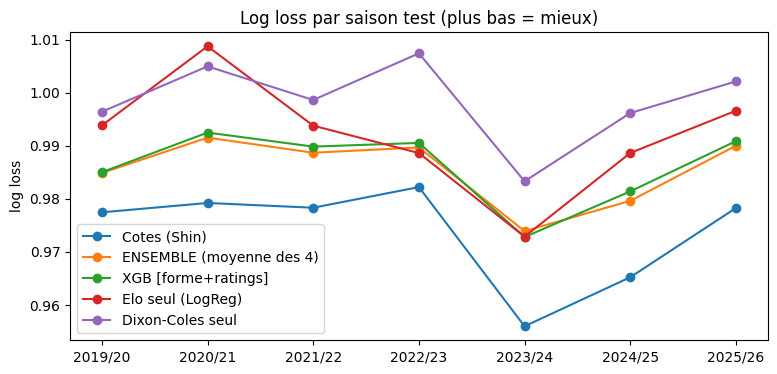

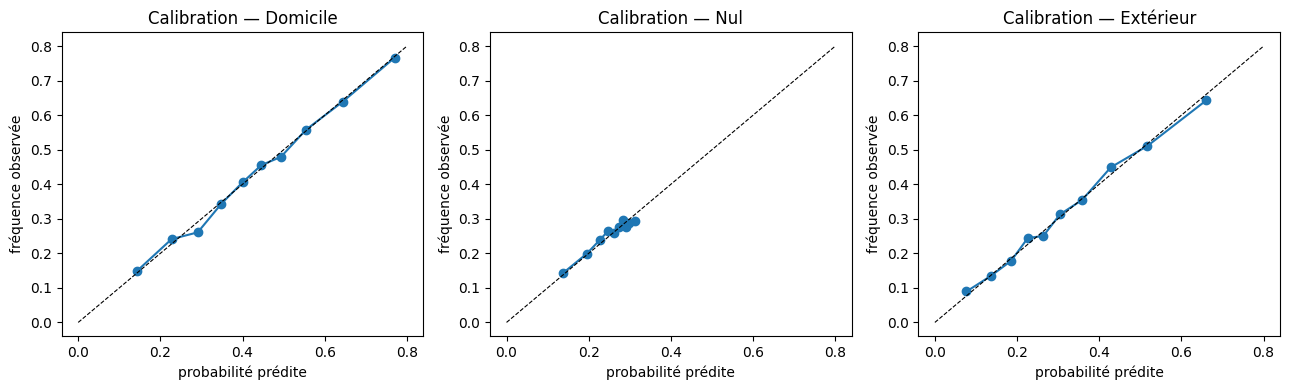

In [11]:
# Log loss par saison et courbe de calibration de l'ensemble
show = ["Cotes (Shin)", "ENSEMBLE (moyenne des 4)", REF, "Elo seul (LogReg)", "Dixon-Coles seul"]
per = pd.DataFrame({k: pd.Series(L[k]).groupby(S[mask]).mean() for k in show})
per.index = [f"{s}/{s+1-2000:02d}" for s in per.index]
ax = per.plot(marker="o", figsize=(9, 4), title="Log loss par saison test (plus bas = mieux)"); ax.set_ylabel("log loss"); plt.show()

pe = P["ENSEMBLE (moyenne des 4)"][mask]
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for k, lab in enumerate(["Domicile", "Nul", "Extérieur"]):
    d = pd.DataFrame({"p": pe[:, k], "o": yy == k}); g = d.groupby(pd.qcut(d.p, 10, duplicates="drop")).mean()
    axs[k].plot(g.p, g.o, "o-"); axs[k].plot([0, .8], [0, .8], "k--", lw=.8); axs[k].set_title(f"Calibration — {lab}")
    axs[k].set_xlabel("probabilité prédite"); axs[k].set_ylabel("fréquence observée")
plt.tight_layout(); plt.show()

## 6. Interprétation : coefficients du modèle parcimonieux (LogReg [ratings+GAP])
Modèle entraîné sur toutes les saisons ≤ 2024/25 ; coefficients standardisés pour la classe « victoire domicile » vs « victoire extérieur ».

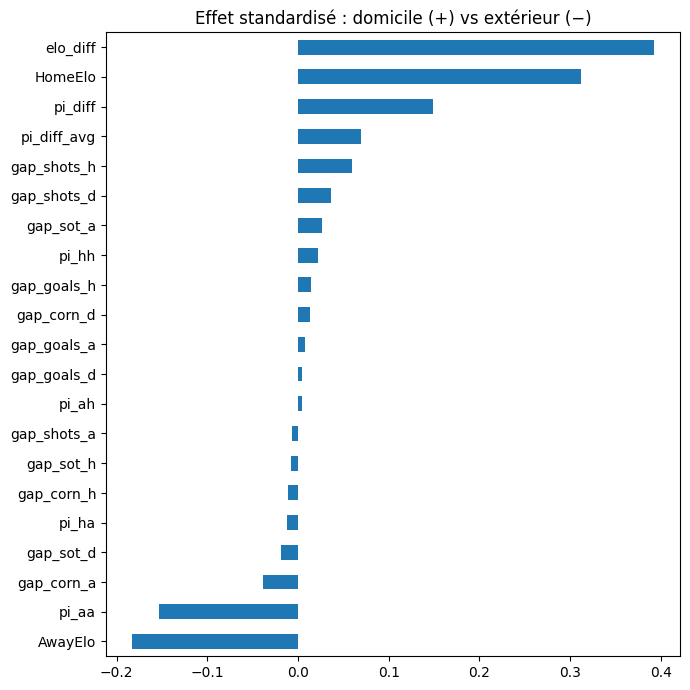

In [12]:
tr = B[B.Season <= max(TEST_SEASONS) - 1]
pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.05, max_iter=3000)).fit(tr[RAT + GAP], tr.y)
coef = pd.Series(pipe[-1].coef_[0] - pipe[-1].coef_[2], index=RAT + GAP).sort_values()
coef.plot.barh(figsize=(7, 7), title="Effet standardisé : domicile (+) vs extérieur (−)"); plt.tight_layout(); plt.show()